In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install geopandas cartopy shapely

In [3]:
import sys
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

PROJECT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection"
sys.path.insert(0, PROJECT_PATH)

In [4]:
from src.config import *
from src.visualization import *
from src.ensemble import multi_model_mean

In [5]:
DATA_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/regridded"
OUTPUT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/processed"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [6]:
datasets_ts_245 = []
datasets_pr_245 = []

datasets_ts_585 = []
datasets_pr_585 = []

for model in MODELS:

    print("Loading future model:", model)

    ts_245 = xr.open_dataset(
        os.path.join(DATA_PATH, f"{model}_ts_ssp245_regridded.nc")
    )

    pr_245 = xr.open_dataset(
        os.path.join(DATA_PATH, f"{model}_pr_ssp245_regridded.nc")
    )

    ts_585 = xr.open_dataset(
        os.path.join(DATA_PATH, f"{model}_ts_ssp585_regridded.nc")
    )

    pr_585 = xr.open_dataset(
        os.path.join(DATA_PATH, f"{model}_pr_ssp585_regridded.nc")
    )

    # période future
    ts_245 = ts_245.sel(time=slice("2040", "2069"))
    pr_245 = pr_245.sel(time=slice("2040", "2069"))

    ts_585 = ts_585.sel(time=slice("2040", "2069"))
    pr_585 = pr_585.sel(time=slice("2040", "2069"))

    datasets_ts_245.append(ts_245)
    datasets_pr_245.append(pr_245)

    datasets_ts_585.append(ts_585)
    datasets_pr_585.append(pr_585)

Loading future model: CNRM-CM6-1
Loading future model: IPSL-CM6A-LR
Loading future model: MPI-ESM1-2-LR


In [7]:
ts_245 = multi_model_mean(datasets_ts_245, "ts")
pr_245 = multi_model_mean(datasets_pr_245, "pr")

ts_585 = multi_model_mean(datasets_ts_585, "ts")
pr_585 = multi_model_mean(datasets_pr_585, "pr")

In [8]:
# Kelvin → Celsius
ts_245 = ts_245 - 273.15
ts_585 = ts_585 - 273.15

# precipitation → mm/month
seconds_per_day = 86400
days_per_month = 30

pr_245 = pr_245 * seconds_per_day * days_per_month
pr_585 = pr_585 * seconds_per_day * days_per_month


In [9]:
ts_hist = xr.open_dataset(
    os.path.join(OUTPUT_PATH, "ts_MMM_historical.nc")
)

pr_hist = xr.open_dataset(
    os.path.join(OUTPUT_PATH, "pr_MMM_historical.nc")
)

ts_hist = ts_hist["ts"]
pr_hist = pr_hist["pr"]

In [10]:
ts_hist_mean = ts_hist.mean("time")
pr_hist_mean = pr_hist.mean("time")

ts_245_mean = ts_245.mean("time")
pr_245_mean = pr_245.mean("time")

ts_585_mean = ts_585.mean("time")
pr_585_mean = pr_585.mean("time")

In [11]:
ts_anom_245 = ts_245_mean - ts_hist_mean
ts_anom_585 = ts_585_mean - ts_hist_mean

pr_anom_245 = pr_245_mean - pr_hist_mean
pr_anom_585 = pr_585_mean - pr_hist_mean

In [12]:
ts_245_season = ts_245.groupby("time.season").mean("time")
ts_585_season = ts_585.groupby("time.season").mean("time")

pr_245_season = pr_245.groupby("time.season").mean("time")
pr_585_season = pr_585.groupby("time.season").mean("time")

ts_hist_season = ts_hist.groupby("time.season").mean("time")
pr_hist_season = pr_hist.groupby("time.season").mean("time")


ts_anom_245_djf = ts_245_season.sel(season="DJF") - ts_hist_season.sel(season="DJF")
ts_anom_245_jja = ts_245_season.sel(season="JJA") - ts_hist_season.sel(season="JJA")

ts_anom_585_djf = ts_585_season.sel(season="DJF") - ts_hist_season.sel(season="DJF")
ts_anom_585_jja = ts_585_season.sel(season="JJA") - ts_hist_season.sel(season="JJA")


pr_anom_245_djf = pr_245_season.sel(season="DJF") - pr_hist_season.sel(season="DJF")
pr_anom_245_jja = pr_245_season.sel(season="JJA") - pr_hist_season.sel(season="JJA")

pr_anom_585_djf = pr_585_season.sel(season="DJF") - pr_hist_season.sel(season="DJF")
pr_anom_585_jja = pr_585_season.sel(season="JJA") - pr_hist_season.sel(season="JJA")

Plotting anomaly maps
Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anomaly_ssp245.png


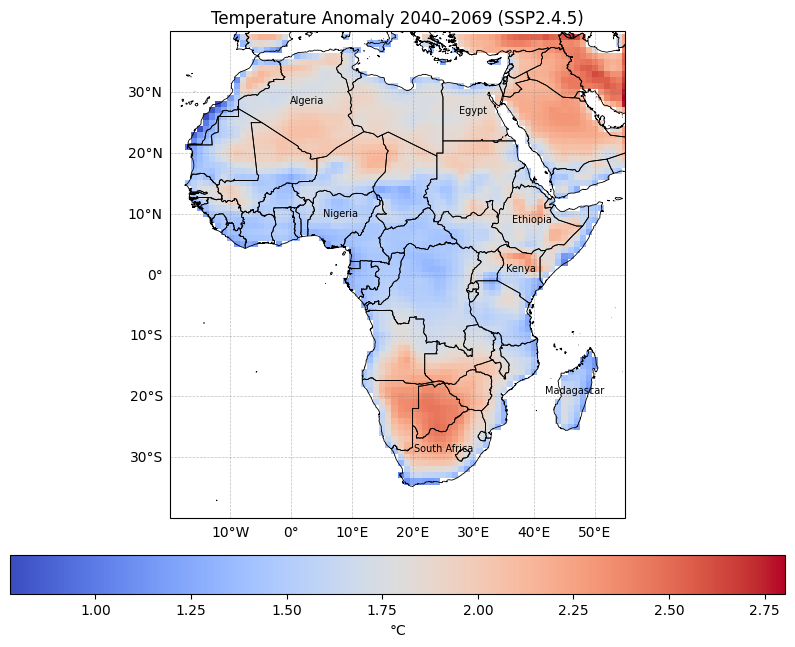

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anomaly_ssp585.png


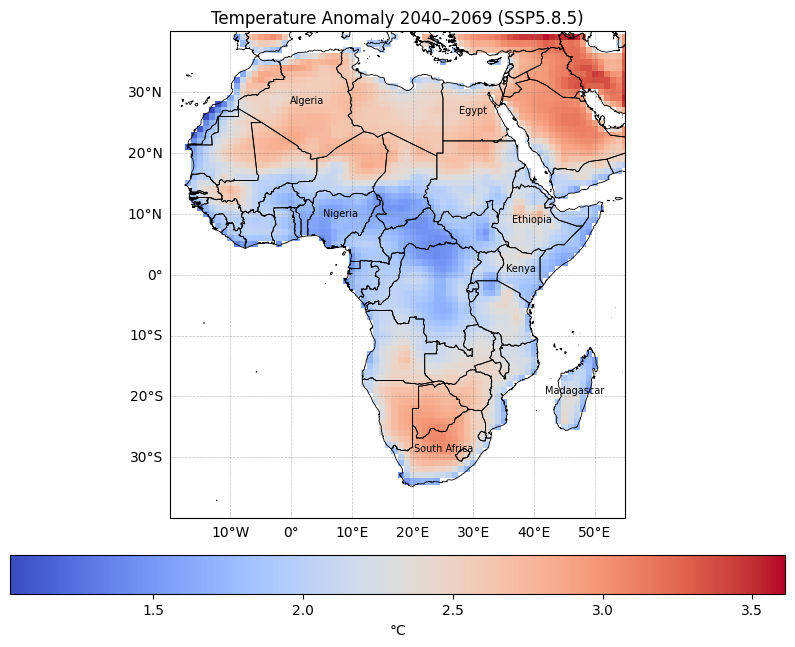

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anomaly_ssp245.png


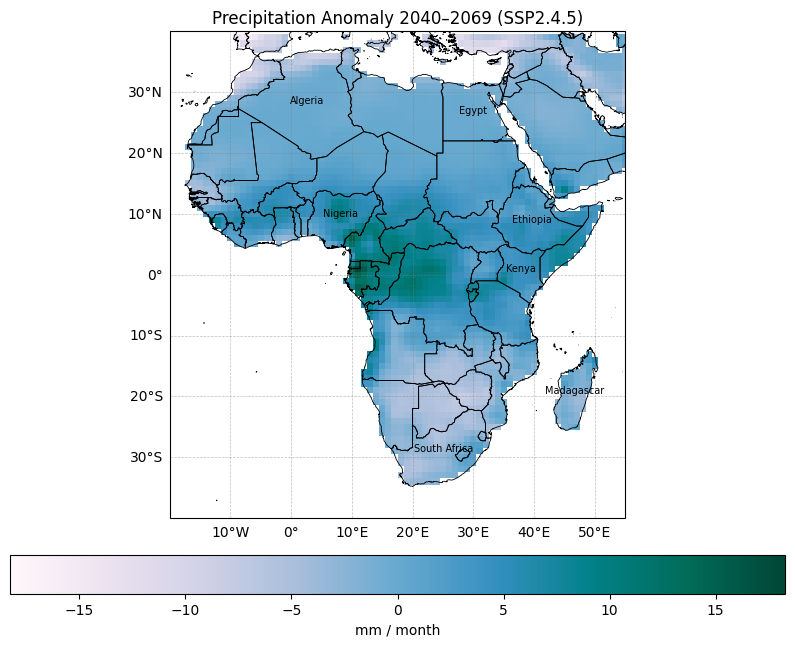

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anomaly_ssp585.png


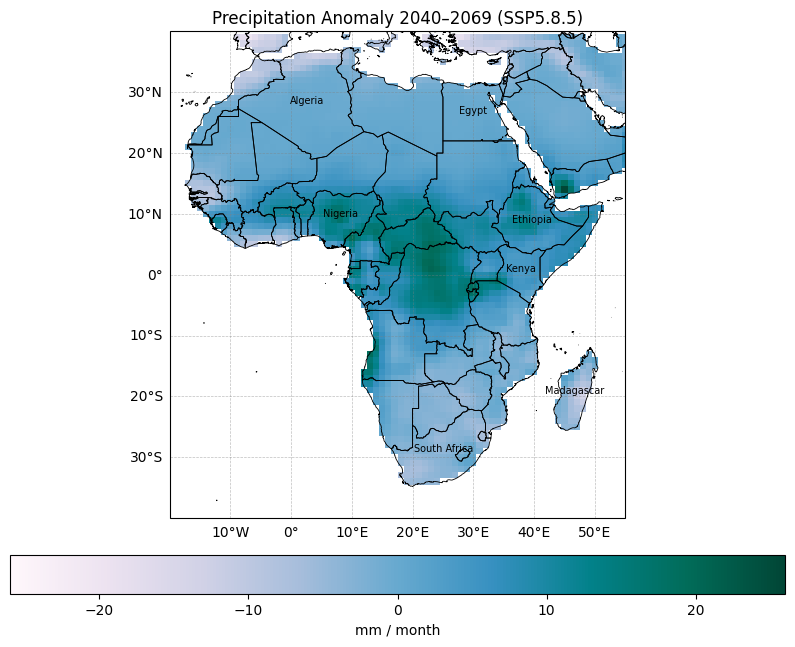

In [13]:
print("Plotting anomaly maps")

plot_africa_map(
    ts_anom_245,
    "Temperature Anomaly 2040–2069 (SSP2.4.5)",
    cmap="RdBu_r",
    save_name="ts_anomaly_ssp245"
)

plot_africa_map(
    ts_anom_585,
    "Temperature Anomaly 2040–2069 (SSP5.8.5)",
    cmap="RdBu_r",
    save_name="ts_anomaly_ssp585"
)

plot_africa_map(
    pr_anom_245,
    "Precipitation Anomaly 2040–2069 (SSP2.4.5)",
    cmap="BrBG",
    save_name="pr_anomaly_ssp245"
)

plot_africa_map(
    pr_anom_585,
    "Precipitation Anomaly 2040–2069 (SSP5.8.5)",
    cmap="BrBG",
    save_name="pr_anomaly_ssp585"
)

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anom_djf_ssp245.png


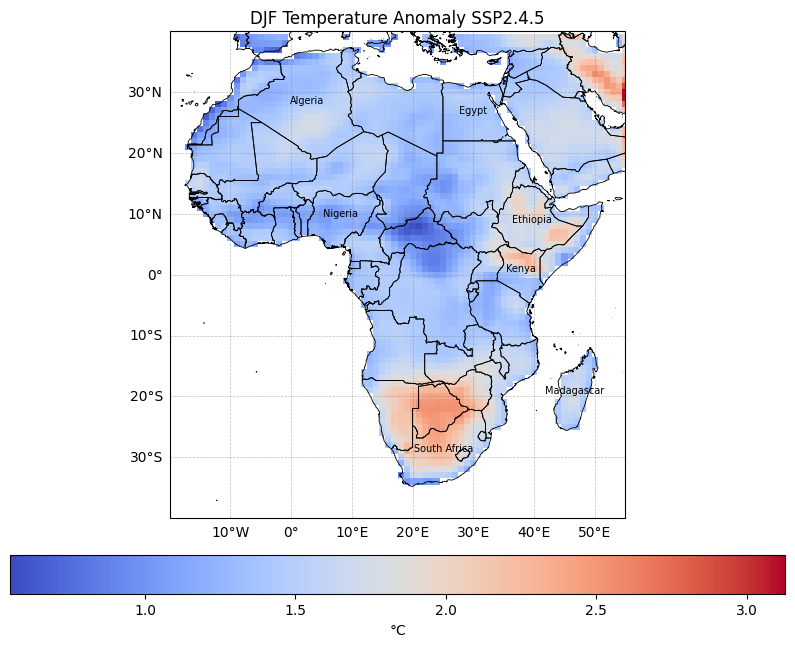

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anom_jja_ssp245.png


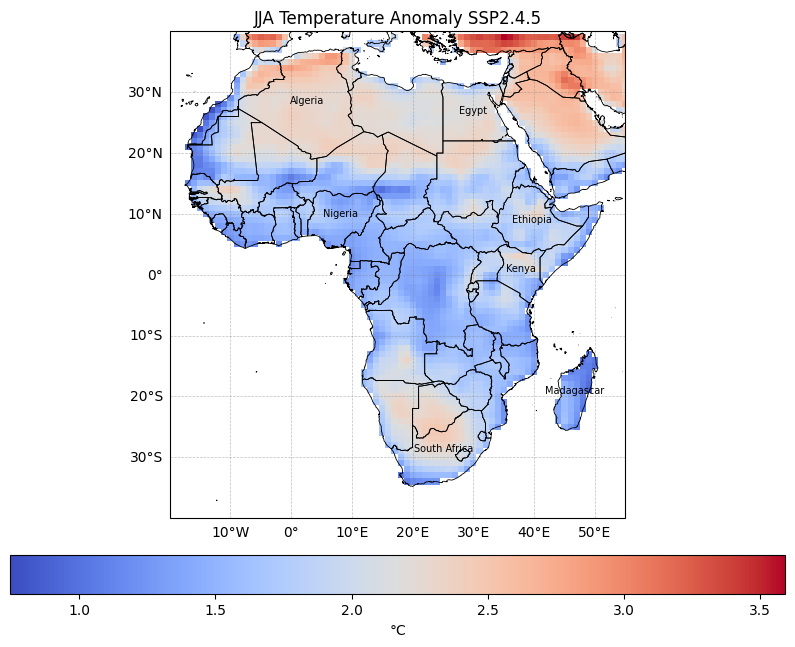

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anom_djf_ssp585.png


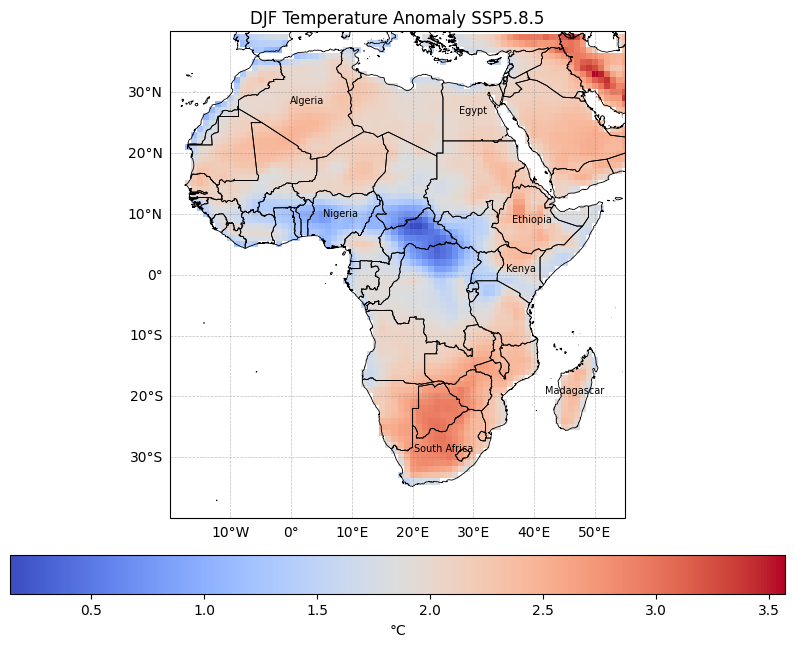

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/ts_anom_jja_ssp585.png


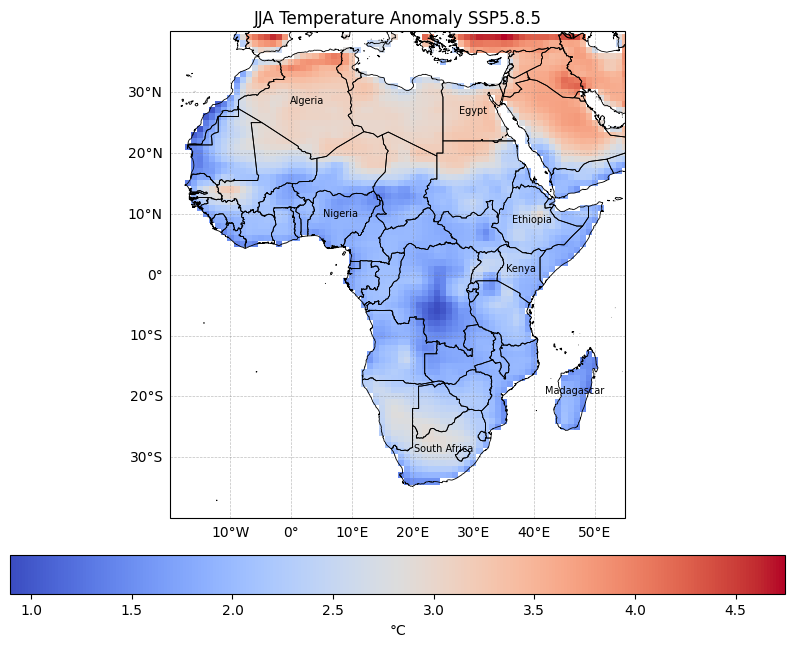

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anom_djf_ssp245.png


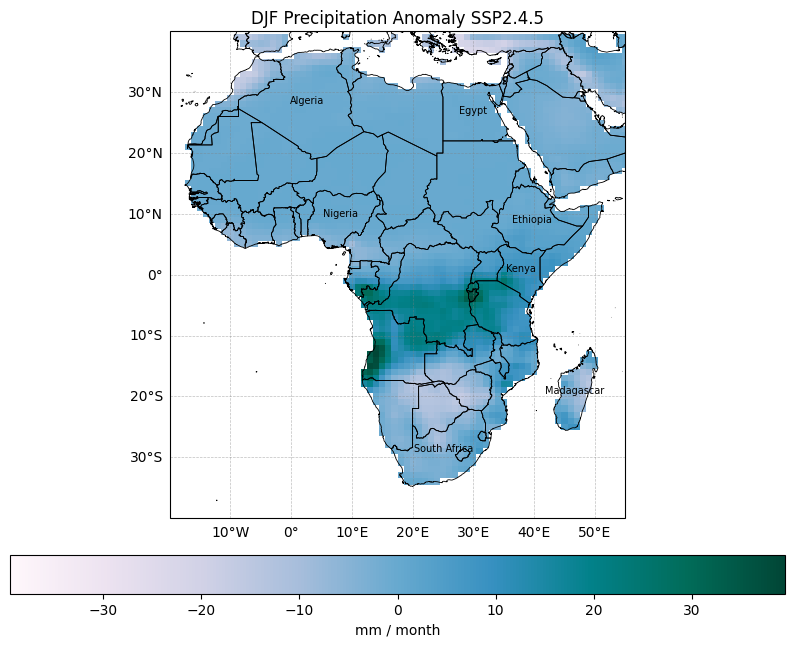

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anom_jja_ssp245.png


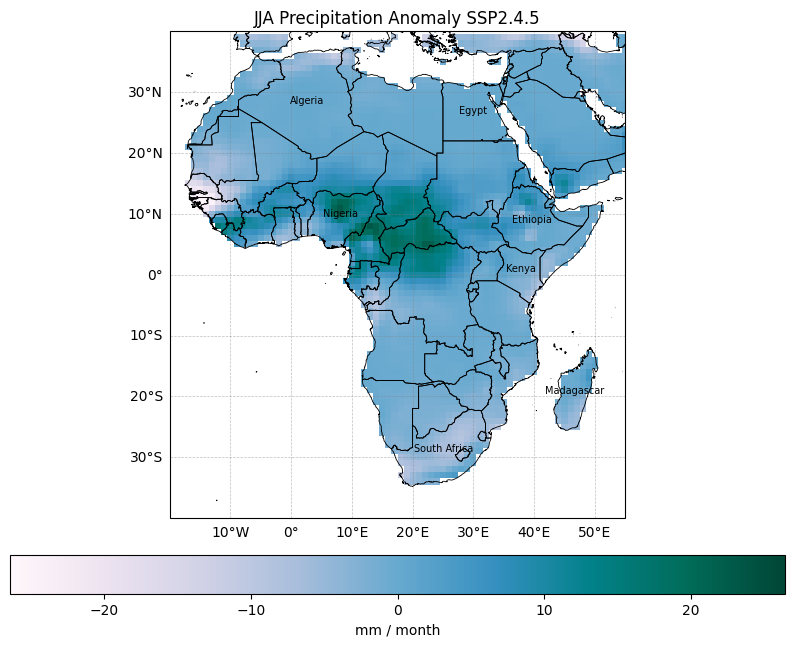

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anom_djf_ssp585.png


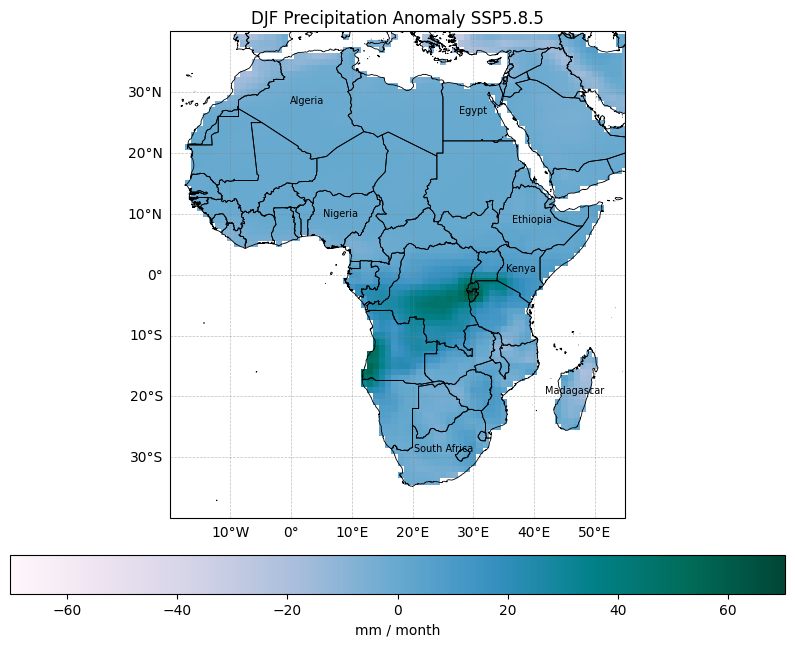

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/pr_anom_jja_ssp585.png


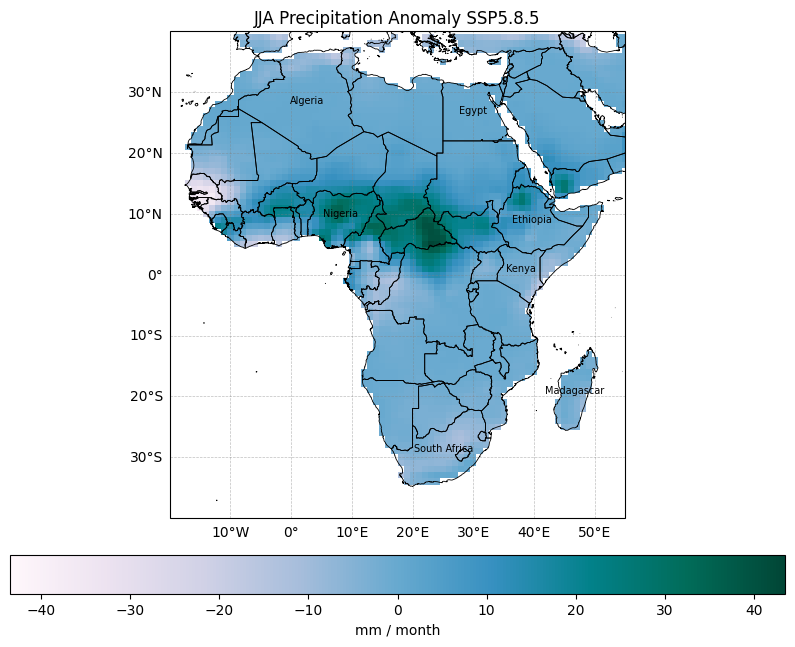

In [14]:
plot_africa_map(ts_anom_245_djf, "DJF Temperature Anomaly SSP2.4.5", cmap="RdBu_r", save_name="ts_anom_djf_ssp245")
plot_africa_map(ts_anom_245_jja, "JJA Temperature Anomaly SSP2.4.5", cmap="RdBu_r", save_name="ts_anom_jja_ssp245")

plot_africa_map(ts_anom_585_djf, "DJF Temperature Anomaly SSP5.8.5", cmap="RdBu_r", save_name="ts_anom_djf_ssp585")
plot_africa_map(ts_anom_585_jja, "JJA Temperature Anomaly SSP5.8.5", cmap="RdBu_r", save_name="ts_anom_jja_ssp585")

plot_africa_map(pr_anom_245_djf, "DJF Precipitation Anomaly SSP2.4.5", cmap="BrBG", save_name="pr_anom_djf_ssp245")
plot_africa_map(pr_anom_245_jja, "JJA Precipitation Anomaly SSP2.4.5", cmap="BrBG", save_name="pr_anom_jja_ssp245")

plot_africa_map(pr_anom_585_djf, "DJF Precipitation Anomaly SSP5.8.5", cmap="BrBG", save_name="pr_anom_djf_ssp585")
plot_africa_map(pr_anom_585_jja, "JJA Precipitation Anomaly SSP5.8.5", cmap="BrBG", save_name="pr_anom_jja_ssp585")

In [15]:
ts_anom_245.to_netcdf(os.path.join(OUTPUT_PATH, "ts_anomaly_ssp245.nc"))
ts_anom_585.to_netcdf(os.path.join(OUTPUT_PATH, "ts_anomaly_ssp585.nc"))

pr_anom_245.to_netcdf(os.path.join(OUTPUT_PATH, "pr_anomaly_ssp245.nc"))
pr_anom_585.to_netcdf(os.path.join(OUTPUT_PATH, "pr_anomaly_ssp585.nc"))

print("Future analysis completed")

Future analysis completed
